# Correlational Analysis

✅ Successfully loaded both energy and AQI datasets.
Resampling 5-minute energy data to hourly averages...
Merging the hourly energy and AQI datasets...
✅ Merge complete. Combined dataset is ready for analysis.
Generating a plot of Power Demand vs. PM2.5 for a sample period...


/tmp/ipykernel_1985/20268964.py:27: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy_hourly_df = energy_df.resample('H').mean()


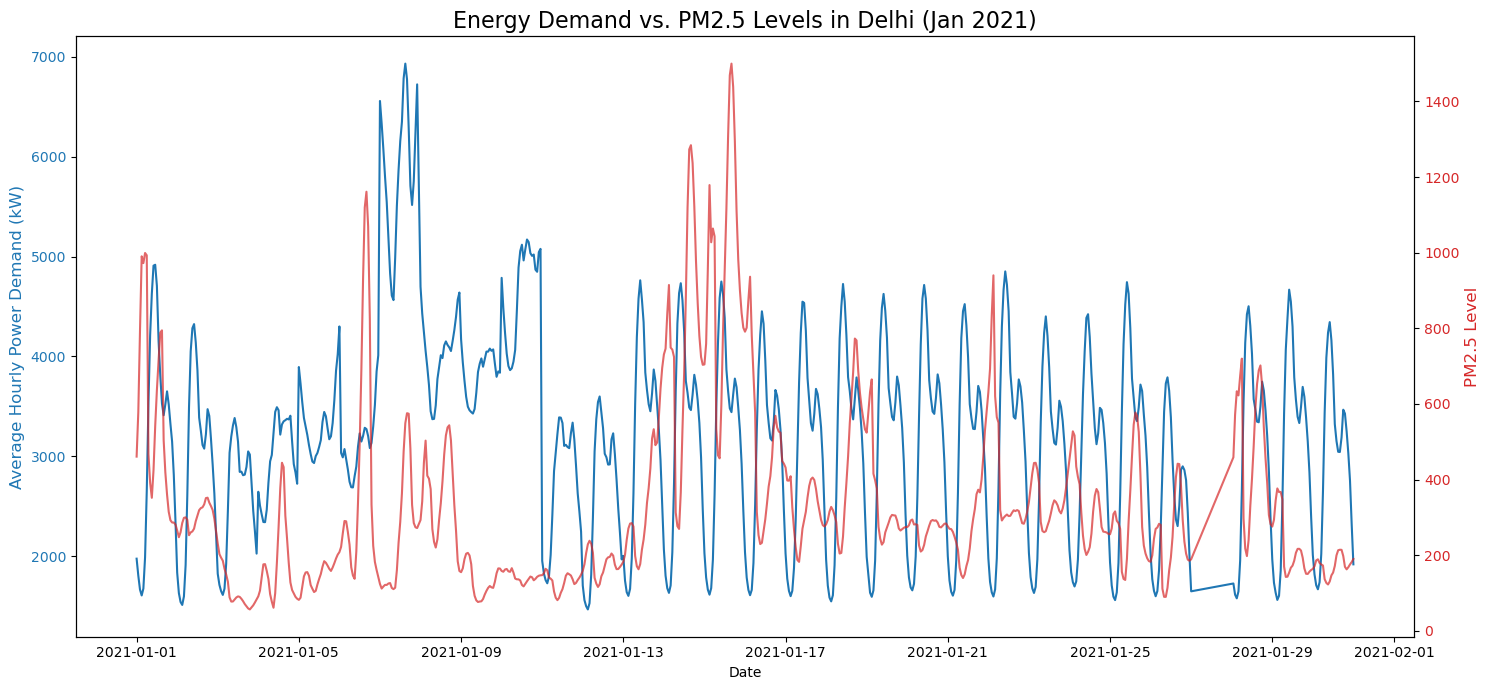


Performing correlation analysis on the merged data...

--- Correlation of All Variables with Power Demand ---
Power_Demand         1.000000
moving_avg_3         0.999734
Temperature          0.432651
Dew_Point            0.273270
Wind_speed           0.250229
Hour                 0.213838
Sl.No                0.168103
Year                 0.164108
Wind_direction       0.108371
o3                   0.035355
Month                0.031003
so2                  0.005653
Day                 -0.022441
no2                 -0.051496
Minute              -0.053115
nh3                 -0.071497
no                  -0.142134
co                  -0.153397
Relative_Humidity   -0.164614
pm10                -0.194716
pm2_5               -0.222872
Pressure            -0.360293
Name: Power_Demand, dtype: float64


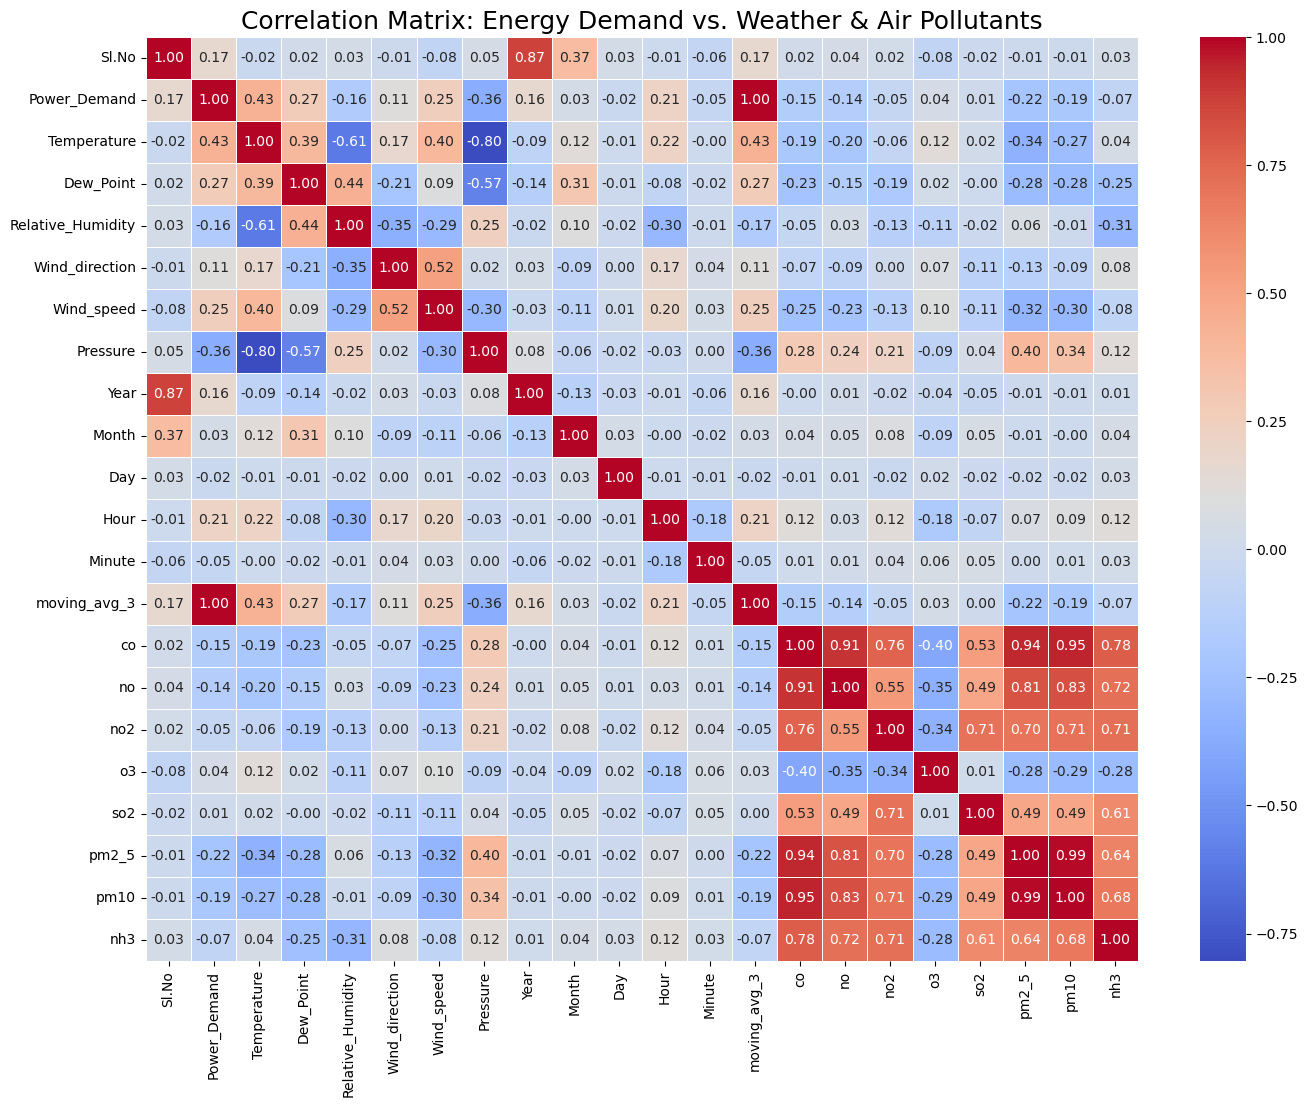


✅ Analysis complete.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Load Both Datasets ---
try:
    # Load your 5-minute energy data
    energy_df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
    
    # Load your hourly AQI data
    aqi_df = pd.read_csv('Data/delhi_aqi.csv')
except FileNotFoundError as e:
    print(f"Error: A file was not found. Please ensure both 'EST_Project_5min_Dataset.csv' and 'delhi_aqi_data.csv' are in the 'Data' folder.")
    print(e)
    exit()

print("✅ Successfully loaded both energy and AQI datasets.")

# --- 2. Prepare and Resample the Energy Data (Your Key Request) ---
# Convert the 'Date_Time' column to a proper datetime object
energy_df['Date_Time'] = pd.to_datetime(energy_df['Date_Time'], format='%d-%m-%Y %H:%M')
energy_df.set_index('Date_Time', inplace=True)

# ** RESAMPLING to HOURLY AVERAGES **
# This aggregates the 5-minute data into hourly averages to match the AQI data.
print("Resampling 5-minute energy data to hourly averages...")
energy_hourly_df = energy_df.resample('H').mean()
energy_hourly_df.reset_index(inplace=True)

# --- 3. Prepare and Merge the AQI Data ---
# Rename the 'date' column in the AQI file to match for an easy merge
aqi_df.rename(columns={'date': 'Date_Time'}, inplace=True)
aqi_df['Date_Time'] = pd.to_datetime(aqi_df['Date_Time'])

print("Merging the hourly energy and AQI datasets...")
# Merge the two hourly datasets based on the common 'Date_Time' column
merged_df = pd.merge(energy_hourly_df, aqi_df, on='Date_Time', how='inner')
merged_df.dropna(inplace=True) # Clean up any rows with missing data after the merge

print("✅ Merge complete. Combined dataset is ready for analysis.")


# --- 4. Create the Comparative Plot ---
print("Generating a plot of Power Demand vs. PM2.5 for a sample period...")

# Plotting a sample period (e.g., January 2021) makes the visualization clear
plot_sample = merged_df[(merged_df['Date_Time'] >= '2021-01-01') & (merged_df['Date_Time'] <= '2021-01-31')]

fig, ax1 = plt.subplots(figsize=(15, 7))

# Plot Power Demand on the primary y-axis
color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Average Hourly Power Demand (kW)', color=color, fontsize=12)
ax1.plot(plot_sample['Date_Time'], plot_sample['Power_Demand'], color=color, label='Power Demand')
ax1.tick_params(axis='y', labelcolor=color)

# Create a secondary y-axis for PM2.5 data because the scales are different
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('PM2.5 Level', color=color, fontsize=12)
ax2.plot(plot_sample['Date_Time'], plot_sample['pm2_5'], color=color, label='PM2.5', alpha=0.7)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Energy Demand vs. PM2.5 Levels in Delhi (Jan 2021)', fontsize=16)
fig.tight_layout()
plt.show()


# --- 5. Perform and Visualize Correlation Analysis ---
print("\nPerforming correlation analysis on the merged data...")

# Select only the numerical columns for the correlation calculation
correlation_df = merged_df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = correlation_df.corr()

print("\n--- Correlation of All Variables with Power Demand ---")
print(correlation_matrix['Power_Demand'].sort_values(ascending=False))

# Create the heatmap
plt.figure(figsize=(16, 12))
sns.heatmap(
    correlation_matrix,
    annot=True,          # Show the numbers on the heatmap
    cmap='coolwarm',     # Use a color scheme that shows positive (red) and negative (blue) correlations
    fmt=".2f",           # Format numbers to two decimal places
    linewidths=.5
)
plt.title('Correlation Matrix: Energy Demand vs. Weather & Air Pollutants', fontsize=18)
plt.show()

print("\n✅ Analysis complete.")


# decompose_analysis

 This script takes your hourly Power_Demand data and breaks it down into its three fundamental components:

Trend: The long-term direction of energy demand over the year, smoothing out the daily ups and downs.

Seasonality: The repeating, predictable pattern of energy use. Since the data is hourly, this will show the "average" 24-hour cycle.

Residuals: The random, unpredictable noise or irregularities left over after the trend and seasonality are removed.

/tmp/ipykernel_1985/3896400901.py:13: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy_hourly_df = energy_df.resample('H').mean()


--- Performing Time Series Decomposition on Power Demand ---


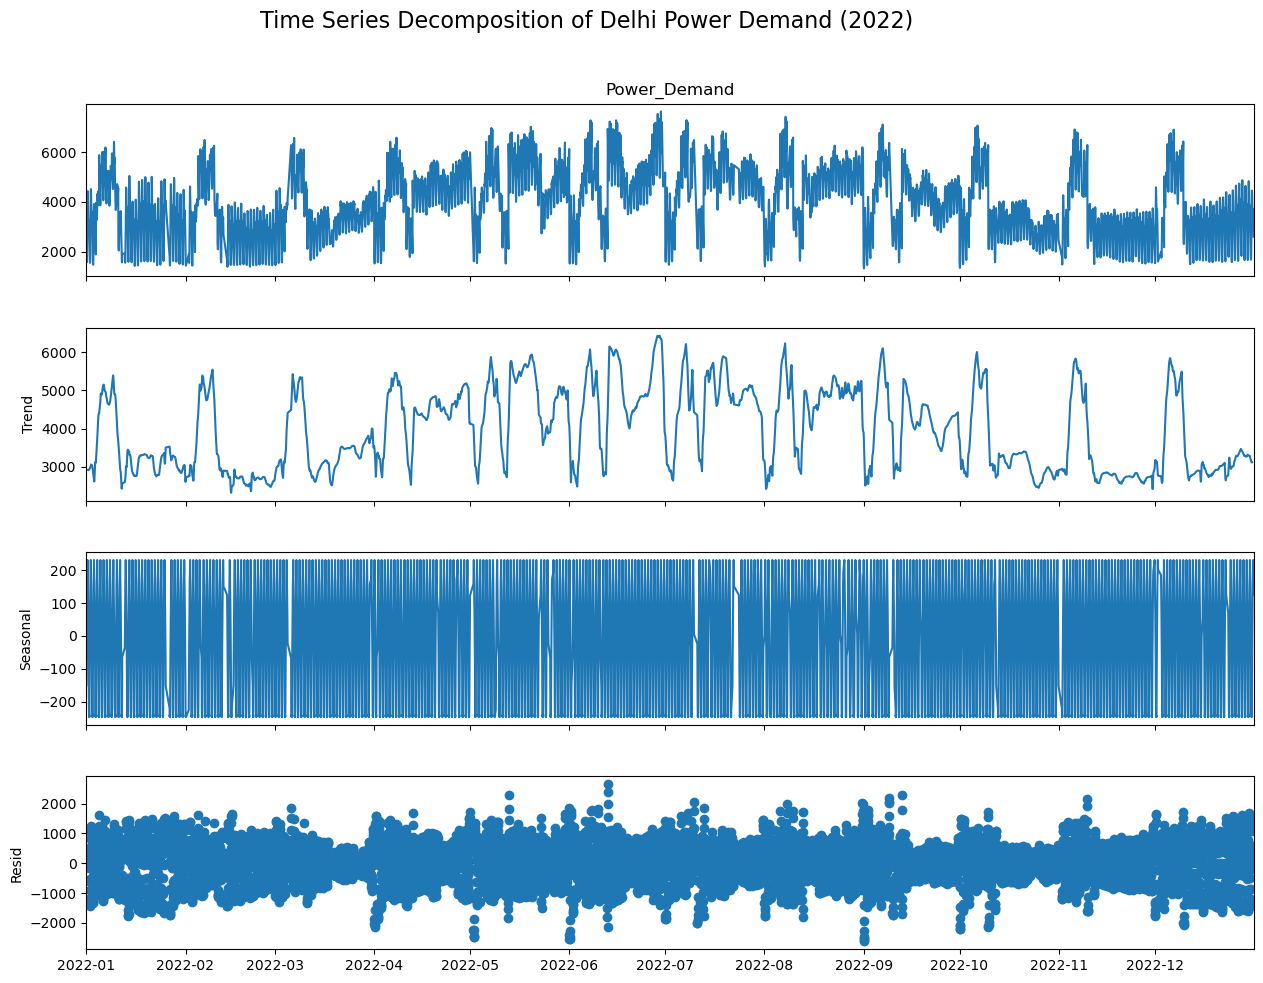

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 1. Load and Prepare Your Merged Data ---
# This assumes you have the 'merged_df' from the previous script.
# We'll reload and prepare it here for a self-contained script.
try:
    # Load energy data
    energy_df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
    energy_df['Date_Time'] = pd.to_datetime(energy_df['Date_Time'], format='%d-%m-%Y %H:%M')
    energy_df.set_index('Date_Time', inplace=True)
    energy_hourly_df = energy_df.resample('H').mean()

    # Load and prepare AQI data
    aqi_df = pd.read_csv('Data/delhi_aqi.csv') # Using your updated filename
    aqi_df.rename(columns={'date': 'Date_Time'}, inplace=True)
    aqi_df['Date_Time'] = pd.to_datetime(aqi_df['Date_Time'])
    aqi_df.set_index('Date_Time', inplace=True)
    
    # For this analysis, we only need the 'Power_Demand' from the merged hourly data
    power_demand_series = energy_hourly_df['Power_Demand'].dropna()

except FileNotFoundError:
    print("Error: Make sure your data files are in the 'Data' folder.")
    exit()

print("--- Performing Time Series Decomposition on Power Demand ---")

# Decompose the time series. Since data is hourly, a daily seasonality period is 24.
# We'll analyze one full year (2022) for clarity.
decomposition = seasonal_decompose(power_demand_series['2022'], model='additive', period=24)

# Plot the decomposed components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.suptitle('Time Series Decomposition of Delhi Power Demand (2022)', y=1.02, fontsize=16)
plt.show()

## lag_analysis

This script investigates if there is a delayed relationship between air quality and energy consumption. It creates new "lagged" features (e.g., PM2.5 level from 1 hour ago, 3 hours ago, 12 hours ago) and then calculates how strongly these past values correlate with the current Power_Demand.

/tmp/ipykernel_1985/2433468259.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  energy_hourly_df = energy_df.resample('H').mean().reset_index()


✅ Data loaded and merged successfully.
--- Performing Lag Analysis ---
Creating lagged features for PM2.5...

--- Correlation of Power Demand with Current and Past PM2.5 Levels ---
Power_Demand      1.000000
pm2_5_lag_24hr   -0.218596
pm2_5            -0.222135
pm2_5_lag_6hr    -0.224330
pm2_5_lag_3hr    -0.229308
pm2_5_lag_1hr    -0.230549
pm2_5_lag_2hr    -0.233413
pm2_5_lag_12hr   -0.241053
Name: Power_Demand, dtype: float64


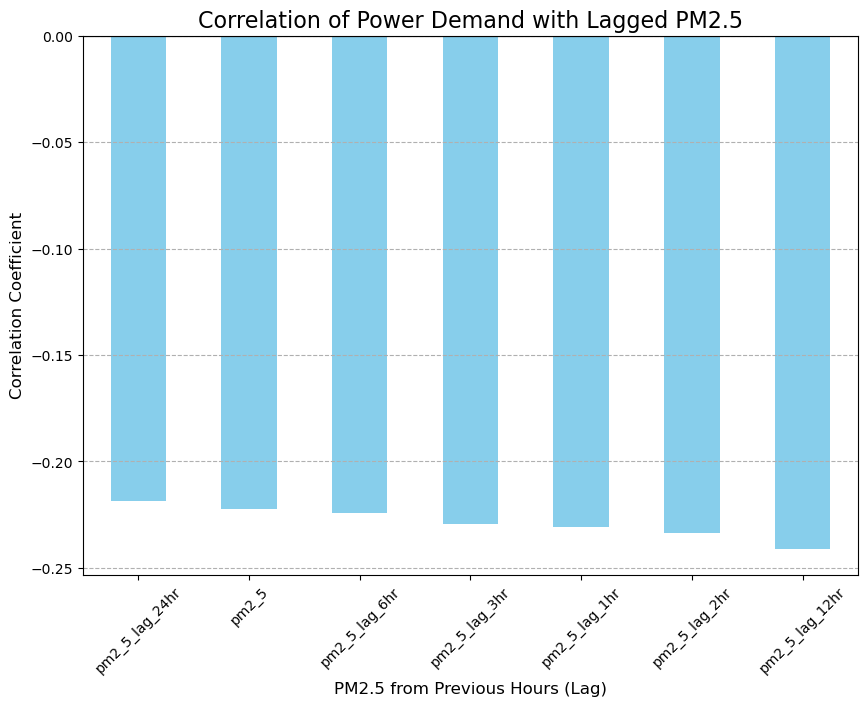


✅ Lag analysis complete.


In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Load and Prepare Merged Data ---
try:
    # Load energy data
    energy_df = pd.read_csv('Data/EST_Project_5min_Dataset.csv')
    # Convert 'Date_Time' to a proper datetime object
    energy_df['Date_Time'] = pd.to_datetime(energy_df['Date_Time'], format='%d-%m-%Y %H:%M')
    # **FIX**: Set 'Date_Time' as the index BEFORE resampling
    energy_df.set_index('Date_Time', inplace=True)
    # Resample to hourly averages
    energy_hourly_df = energy_df.resample('H').mean().reset_index()
    
    # Load and prepare AQI data
    aqi_df = pd.read_csv('Data/delhi_aqi.csv')
    aqi_df.rename(columns={'date': 'Date_Time'}, inplace=True)
    aqi_df['Date_Time'] = pd.to_datetime(aqi_df['Date_Time'])
    
    # Merge the two datasets
    merged_df = pd.merge(energy_hourly_df, aqi_df, on='Date_Time', how='inner').dropna()

except FileNotFoundError:
    print("Error: Make sure 'EST_Project_5min_Dataset.csv' and 'delhi_aqi.csv' are in the 'Data' folder.")
    exit()

print("✅ Data loaded and merged successfully.")
print("--- Performing Lag Analysis ---")

# --- 2. Create Lagged Features ---
# We'll create columns for PM2.5 levels from several hours ago.
# The .shift(n) function gets the value from 'n' rows (hours) before.
print("Creating lagged features for PM2.5...")
merged_df['pm2_5_lag_1hr'] = merged_df['pm2_5'].shift(1)
merged_df['pm2_5_lag_2hr'] = merged_df['pm2_5'].shift(2)
merged_df['pm2_5_lag_3hr'] = merged_df['pm2_5'].shift(3)
merged_df['pm2_5_lag_6hr'] = merged_df['pm2_5'].shift(6)
merged_df['pm2_5_lag_12hr'] = merged_df['pm2_5'].shift(12)
merged_df['pm2_5_lag_24hr'] = merged_df['pm2_5'].shift(24)

# Drop the initial rows that will have NaN values after shifting
merged_df.dropna(inplace=True)

# --- 3. Analyze the Correlation of Lagged Features ---
# We want to see how these new lagged features correlate with the CURRENT Power_Demand.
lag_columns = [
    'Power_Demand',
    'pm2_5', # The current PM2.5 level for comparison
    'pm2_5_lag_1hr',
    'pm2_5_lag_2hr',
    'pm2_5_lag_3hr',
    'pm2_5_lag_6hr',
    'pm2_5_lag_12hr',
    'pm2_5_lag_24hr'
]

# Calculate the correlation matrix for only these columns
lag_correlation = merged_df[lag_columns].corr()

print("\n--- Correlation of Power Demand with Current and Past PM2.5 Levels ---")
# Isolate the correlations with Power_Demand and print them
power_demand_lags = lag_correlation['Power_Demand'].sort_values(ascending=False)
print(power_demand_lags)

# --- 4. Visualize the Lag Correlations ---
plt.figure(figsize=(10, 7))
power_demand_lags.drop('Power_Demand').plot(kind='bar', color='skyblue')
plt.title('Correlation of Power Demand with Lagged PM2.5', fontsize=16)
plt.xlabel('PM2.5 from Previous Hours (Lag)', fontsize=12)
plt.ylabel('Correlation Coefficient', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--')
plt.axhline(0, color='black', linewidth=0.8) # Add a zero line for reference
plt.show()

print("\n✅ Lag analysis complete.")
